In [10]:
import torch
import numpy as np
import cv2
from tqdm import tqdm
from torchvision import transforms
from transformers import TimesformerForVideoClassification
import imageio
from IPython.display import display, Image
import io
import torch.nn.functional as F

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimesformerForVideoClassification.from_pretrained(
    "./finetuned_model",
    trust_remote_code=True
)

model.eval().to(device)

TimesformerForVideoClassification(
  (timesformer): TimesformerModel(
    (embeddings): TimesformerEmbeddings(
      (patch_embeddings): TimesformerPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (time_drop): Dropout(p=0.0, inplace=False)
    )
    (encoder): TimesformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x TimesformerLayer(
          (drop_path): Identity()
          (attention): TimeSformerAttention(
            (attention): TimesformerSelfAttention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
            )
            (output): TimesformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): TimesformerIntermediate(
            (dense

In [3]:
model.classifier

Linear(in_features=768, out_features=10, bias=True)

In [1]:
def segment_video(
    video_path,
    window_size=20,
    overlap=0.5
):
    import cv2
    import numpy as np
    import torch
    from torchvision import transforms

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    assert 0 <= overlap < 1, "overlap must be in [0, 1)"

    stride = int(window_size * (1 - overlap))
    if stride == 0:
        stride = 1  # avoid infinite loop

    results = []

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    start_frame = 0

    while start_frame + window_size <= total_frames:

        frames = []

        for idx in range(start_frame, start_frame + window_size):
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        if len(frames) == window_size:
            video_tensor = torch.tensor(
                np.array(frames),
                dtype=torch.float32
            ) / 255.0  # normalize to [0,1]

            video_tensor = video_tensor.permute(0, 3, 1, 2)  # T,C,H,W
            video_tensor = transform(video_tensor)

            results.append(video_tensor)

        start_frame += stride
        print(f"Segmented {start_frame} / {total_frames} frames", end='\r')

    cap.release()
    return results

In [2]:
test_path = "test_data/Real Madrid vs Benfica _ Key Moments _ UEFA Champions League 2026.mp4"
test_data = segment_video(test_path)

KeyboardInterrupt: 

In [6]:
# def predict_segments_timesformer(
#     video_path,
#     model,
#     num_frames=20,
#     segment_seconds=10,
#     overlap=0.0,          # 0.5 = 50% overlap
#     device="cuda"
# ):
#     model.eval()
#     cap = cv2.VideoCapture(video_path)

#     fps = cap.get(cv2.CAP_PROP_FPS)
#     total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

#     segment_frames = int(segment_seconds * fps)
#     stride = int(segment_frames * (1 - overlap))

#     results = []
#     start_frame = 0

#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.Normalize(
#             mean=[0.485, 0.456, 0.406],
#             std=[0.229, 0.224, 0.225]
#         )
#     ])

#     while start_frame + segment_frames <= total_frames:

#         # Sample evenly inside this segment
#         frame_indices = np.linspace(
#             start_frame,
#             start_frame + segment_frames - 1,
#             num_frames
#         ).astype(int)

#         frames = []
#         for idx in frame_indices:
#             cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#             ret, frame = cap.read()
#             if not ret:
#                 break
#             frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#             frames.append(frame)

#         if len(frames) == num_frames:
#             video_tensor = torch.tensor(
#                 np.array(frames),
#                 dtype=torch.float32
#             ) / 255.0

#             video_tensor = video_tensor.permute(0, 3, 1, 2)  # T,C,H,W
#             video_tensor = transform(video_tensor)
#             video_tensor = video_tensor.unsqueeze(0).to(device)  # B,T,C,H,W

#             with torch.no_grad():
#                 with torch.amp.autocast("cuda"):
#                     outputs = model(video_tensor)
#                     probs = torch.softmax(outputs.logits, dim=1)

#             label = probs.argmax(dim=1).item()
#             confidence = probs.max().item()

#             results.append({
#                 "start_time": start_frame / fps,
#                 "end_time": (start_frame + segment_frames) / fps,
#                 "label": label,
#                 "confidence": confidence
#             })

#         start_frame += stride

#     cap.release()
#     return results

In [ ]:
results=[]
for segment in tqdm(test_data):    
    inp = segment.unsqueeze(0).to(device)  # Add batch dimension and move to device
    with torch.no_grad():
        outputs = model(inp)
        logits = outputs.logits
        predicted_class_id = logits.argmax(-1).item()
        predicted_label = model.config.id2label[predicted_class_id]
        results.append(predicted_label)

100%|██████████| 60/60 [00:17<00:00,  3.42it/s]


In [ ]:

def show_segment_as_gif(video_tensor, fps=24):
    video_tensor = video_tensor.detach().cpu()

    mean = torch.tensor([0.485, 0.456, 0.406], device=video_tensor.device).view(1,3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=video_tensor.device).view(1,3,1,1)

    video_tensor = video_tensor * std + mean
    video_tensor = torch.clamp(video_tensor, 0, 1)

    frames = (video_tensor.permute(0,2,3,1).numpy() * 255).astype(np.uint8)

    buffer = io.BytesIO()
    imageio.mimsave(buffer, frames, format="GIF", duration=1/fps)
    buffer.seek(0)

    display(Image(data=buffer.read()))


def show_segments_with_optional_labels(
    segments,
    model,
    device="cuda",
    fps=5,
    threshold=0.6
):
    """
    segments: list of tensors (T, C, H, W)
    model: TimeSformer model
    device: "cuda" or "cpu"
    fps: FPS for GIF display
    threshold: confidence threshold for showing a label
    """
    model.eval()
    
    for i, segment in enumerate(tqdm(segments, desc="Segments")):
        # Display GIF
        print(f"\nSegment {i}")
        show_segment_as_gif(segment, fps=fps)
        
        # Predict
        inp = segment.unsqueeze(0).to(device)  # B,T,C,H,W
        with torch.no_grad():
            outputs = model(inp)
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)
            max_prob, predicted_class_id = probs.max(dim=-1)
            max_prob = max_prob.item()
            predicted_class_id = predicted_class_id.item()
            
            if max_prob < threshold:
                predicted_label = "Nothing to highlight"
            else:
                predicted_label = model.config.id2label[predicted_class_id]
        
        # Display label + confidence
        print(f"Predicted Label: {predicted_label} | Confidence: {max_prob:.2f}")

Segments:   0%|          | 0/1 [00:00<?, ?it/s]


Segment 0


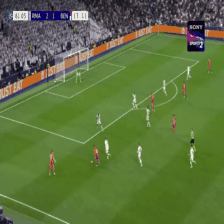

Segments: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]

Predicted Label: longpass | Confidence: 0.79


In [ ]:
show_segments_with_optional_labels(test_data[54:55],model)

In [ ]:
results

['ontarget',
 'ontarget',
 'ontarget',
 'ontarget',
 'ontarget',
 'corner',
 'shortpass',
 'corner',
 'goalkick',
 'shortpass',
 'corner',
 'corner',
 'corner',
 'substitution',
 'goalkick',
 'penalty',
 'corner',
 'penalty',
 'shortpass',
 'substitution',
 'ontarget',
 'penalty',
 'foul',
 'corner',
 'corner',
 'corner',
 'ontarget',
 'substitution',
 'substitution',
 'corner',
 'corner',
 'corner',
 'longpass',
 'substitution',
 'goalkick',
 'corner',
 'foul',
 'corner',
 'corner',
 'corner',
 'substitution',
 'corner',
 'shortpass',
 'corner',
 'longpass',
 'longpass',
 'longpass',
 'ontarget',
 'throw-in',
 'shortpass',
 'corner',
 'throw-in',
 'corner',
 'penalty',
 'shortpass',
 'corner',
 'penalty',
 'ontarget',
 'ontarget',
 'ontarget']